# Day 128 — Hierarchical Clustering: Dendrograms & Agglomerative Segmentation
**Month 7 | Week 2 | Day 4 | RetailPulse India 500 rows seed=121**

---

| | |
|---|---|
| **Max Score** | 80 pts + 10★ bonus |
| **Tools** | scikit-learn, scipy, pandas, matplotlib, seaborn |
| **GitHub** | Month7-AdvancedML-Portfolio |

---

## Why Hierarchical After K-Means + DBSCAN?

You now know two clustering algorithms. Here's where each fits:

| Algorithm | Needs K? | Handles noise? | Best for |
|---|---|---|---|
| K-Means | ✅ Yes | ❌ No | Balanced, spherical segments |
| DBSCAN | ❌ No | ✅ Yes | Arbitrary shapes + outlier detection |
| **Hierarchical** | **Choose after** | ❌ No | **Exploratory — no K guess needed upfront** |

**The core advantage of Hierarchical Clustering:** it gives you a **dendrogram** — a tree diagram that shows how every data point relates to every other. You cut the tree at a height → you get clusters. Cut higher → fewer clusters. Cut lower → more clusters.

No iteration needed. No random restarts. Fully deterministic.

> **Freelance signal:** When a client says *"we have no idea how many customer groups we have — can you tell us?"*, hierarchical clustering + a dendrogram is your first deliverable. It gives them a visual they can understand before you assign anyone to a segment.

---

## How Agglomerative Clustering Works

**Bottom-up (agglomerative) approach:**

```
1. Start: every point is its own cluster (N clusters)
2. Merge the two closest clusters
3. Repeat until 1 cluster remains
4. Record the merge history → this IS the dendrogram
5. Cut the dendrogram at the height that maximises within-cluster cohesion
```

**The distance between clusters is controlled by the linkage method:**

| Linkage | Measures distance as... | Behaviour |
|---|---|---|
| `ward` | Increase in total within-cluster variance | Compact, evenly-sized clusters (most common) |
| `complete` | Max distance between any two points | Tight, non-chaining clusters |
| `average` | Mean distance between all point pairs | Balance of ward and complete |
| `single` | Min distance between any two points | Can chain into long clusters |

> **Default recommendation:** Always start with `ward`. Switch to `complete` if ward produces very unequal cluster sizes.

---

> **Comment-skeleton rule:** Write your goal + method in plain English before each code block.  
> Complete every task before opening Section 4 (Answer Key).  
> ⚠️ If your dendrogram shows only 2 visible branches, your `truncate_mode` parameter may be off — re-read C2.


---
## Section 1 — Raw Data
⚠️ **Do NOT modify this cell. All work happens in Sections 2–3.**

In [1]:
# SECTION 1 — RAW DATA (read-only)
# Goal: Reproduce the RetailPulse India customer dataset used across Month 7.
# Method: numpy + pandas with seed=121 for exact reproducibility.

import numpy as np
import pandas as pd

np.random.seed(121)
n = 500

states = ['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu', 'Gujarat',
          'Rajasthan', 'West Bengal', 'Uttar Pradesh']
categories = ['Electronics', 'Apparel', 'Home & Kitchen', 'Books', 'Sports']

df_raw = pd.DataFrame({
    'customer_id':        range(1001, 1501),
    'age':                np.random.randint(18, 65, n),
    'annual_income_lpa':  np.round(np.random.uniform(3.0, 25.0, n), 2),
    'monthly_spend':      np.round(np.random.uniform(500, 15000, n), 2),
    'purchase_frequency': np.random.randint(1, 30, n),
    'avg_order_value':    np.round(np.random.uniform(200, 5000, n), 2),
    'loyalty_score':      np.random.randint(1, 100, n),
    'returns_count':      np.random.randint(0, 10, n),
    'state':              np.random.choice(states, n),
    'preferred_category': np.random.choice(categories, n),
    'churned':            np.random.choice([0, 1], n, p=[0.75, 0.25])
})

print(f"Shape: {df_raw.shape}")
print(df_raw.head())


Shape: (500, 11)
   customer_id  age  annual_income_lpa  monthly_spend  purchase_frequency  \
0         1001   20              24.19       10204.80                   5   
1         1002   39              10.97        8469.58                  22   
2         1003   26               3.06        2347.30                   4   
3         1004   49               4.25        9792.66                   8   
4         1005   19               8.41        5634.99                  17   

   avg_order_value  loyalty_score  returns_count          state  \
0          4925.90             64              5          Delhi   
1          2401.62             17              6  Uttar Pradesh   
2          1926.13             28              5          Delhi   
3           341.52              6              6     Tamil Nadu   
4           334.03              4              4          Delhi   

  preferred_category  churned  
0            Apparel        0  
1     Home & Kitchen        1  
2             Sports 

---
## Section 2 — Practice Guide

Complete **C1 → C6** in order. Bonus task C7 is optional (+10★).

---

### C1 — Feature Selection & Scaling (10 pts)

**Your task:**
1. Select these 5 features for clustering: `age`, `annual_income_lpa`, `monthly_spend`, `purchase_frequency`, `avg_order_value`
2. Confirm `churned` is **not** in your feature matrix (data leakage rule from Day 125)
3. Apply `StandardScaler` — store the result as `X_scaled` (numpy array)
4. Print shape of `X_scaled`

> Same features as Days 126–127 — the dataset is consistent so you can compare all three algorithms at the end.

---

### C2 — Dendrogram: Finding the Right Number of Clusters (20 pts)

**Your task:**
1. Use `scipy.cluster.hierarchy.linkage` with `method='ward'` on `X_scaled`
2. Plot a **truncated dendrogram** using `scipy.cluster.hierarchy.dendrogram`:
   - `truncate_mode='level'`, `p=5` (shows last 5 merge levels — readable on 500 rows)
   - Title: `"Hierarchical Clustering Dendrogram — RetailPulse India"`
   - x-label: `"Customer Index / Cluster"`, y-label: `"Ward Linkage Distance"`
   - Figure size: `(14, 6)`
3. Identify the **longest vertical line that no horizontal line crosses** — this gap tells you the natural K
4. Write a 1-sentence justification: *"I chose K=___ because the largest gap in linkage distance occurs between height ___ and height ___."*

> **Reading the dendrogram:** horizontal cuts = you're forcing that many clusters. Look for the largest vertical gap — that's nature suggesting K.

---

### C3 — Fit Agglomerative Clustering (15 pts)

**Your task:**
1. Import `AgglomerativeClustering` from `sklearn.cluster`
2. Fit with `n_clusters` = your K from C2, `linkage='ward'`
3. Add cluster labels to `df_raw` as column `'hc_cluster'`
4. Print `value_counts` of `'hc_cluster'` — note cluster sizes
5. Print total number of unique clusters found

> Unlike K-Means, there is no `inertia_` attribute. AgglomerativeClustering is deterministic — re-running gives identical results.

---

### C4 — Cluster Profiles (20 pts)

**Your task:**
Build a summary table grouped by `hc_cluster` showing:

| Column | Aggregation |
|---|---|
| `annual_income_lpa` | mean |
| `monthly_spend` | mean |
| `purchase_frequency` | mean |
| `avg_order_value` | mean |
| `churned` | mean (= churn rate) |

Round all values to 2 decimal places. Print the full table.

> This is the deliverable you hand the client: *"Here are your N customer segments and what defines each one."*

---

### C5 — Business Interpretation (10 pts)

**Your task:** Write **one NRA sentence per cluster** using this exact format:

> *"Cluster X has [metric] of [value], driven by [reason], so we should [specific action]."*

Rules:
- Use **actual numbers** from your C4 profile table (not approximations)
- Name a **specific** business action (not "investigate further" or "monitor")
- NRA = Number → Reason → Action. Every sentence must have all three.

Example structure (fill in your actual values):  
*"Cluster 2 has the highest monthly spend of ₹9,847 and lowest churn rate of 0.12, driven by high purchase frequency, so we should offer them an exclusive loyalty tier with early access to new product launches."*

---

### C6 — Three-Algorithm Comparison (5 pts)

**Your task:** Fill in this comparison table using **your actual results** from Days 126, 127, and 128:

| Algorithm | K/Clusters Found | Silhouette Score | Noise Points | Best Use Case |
|---|---|---|---|---|
| K-Means (Day 126) | ? | ? | 0 | Balanced spherical segments |
| DBSCAN (Day 127) | ? | ? | ? | Arbitrary shape + outliers |
| Hierarchical (Day 128) | ? | compute now | 0 | Exploratory, visual client brief |

Compute `silhouette_score` for your hierarchical labels and add it to the table.  
Write 1 sentence: *"For the RetailPulse India dataset, I recommend ___ because ___."*

---

### C7 — Bonus: Linkage Method Comparison (10★)

**Your task:**
1. Fit `AgglomerativeClustering` with the same K but with 3 linkage methods: `ward`, `complete`, `average`
2. For each, compute `silhouette_score`
3. Create a bar chart comparing the 3 silhouette scores:
   - Title: `"Linkage Method Comparison — Silhouette Score"`
   - Bars colour-coded: ward=`#1F3864`, complete=`#2E75B6`, average=`#70AD47`
4. Save as `day128_linkage_comparison.png` (**`savefig()` before `plt.show()`**)
5. 1-sentence conclusion: *"Ward linkage / Complete linkage / Average linkage performs best because ___."*


---
## Section 3 — Concept Notes

### What is Hierarchical Clustering?

Hierarchical clustering builds a **complete tree of all possible groupings** rather than jumping to a fixed K. The output is a dendrogram — a binary tree where:
- **Leaves** = individual data points
- **Internal nodes** = merge events
- **Y-axis height** = distance at which two clusters merged
- **Horizontal cut at height h** = produces clusters that existed just before height h

**Two types:**
- **Agglomerative (bottom-up):** Start with N singletons, merge upward. Standard and most used.
- **Divisive (top-down):** Start with 1 cluster, split downward. Rare in practice.

---

### Ward Linkage — The Variance Minimisation Rule

Ward linkage merges the two clusters that produce the **smallest increase in total within-cluster sum of squares (WCSS)**. This is the same objective function as K-Means — which is why Ward + Agglomerative often produces similar results to K-Means with appropriate K.

**Formula (conceptual):**
```
Δ(merge A, B) = WCSS(A∪B) − WCSS(A) − WCSS(B)
```
Pick the merge with the smallest Δ.

---

### Reading a Dendrogram

```
Height (y-axis):  Higher = more distant merge
                  Large vertical gap = natural cluster boundary

How to choose K:
  1. Find the longest vertical line with no horizontal crossing
  2. Count the number of vertical lines at that height level
  3. That count = your optimal K
```

**Practical rule:** Use `truncate_mode='level', p=5` for 500+ row datasets — plotting all 500 leaves creates an unreadable x-axis.

---

### Silhouette Score (recap from Day 126)

```
s(i) = (b(i) − a(i)) / max(a(i), b(i))

a(i) = mean distance to points in same cluster  →  cohesion
b(i) = mean distance to points in nearest other cluster  →  separation

Range: −1 to +1
  > 0.5  = strong clustering
  0.2–0.5 = moderate
  < 0.2  = weak or overlapping clusters
```

---

### When to Choose Each Algorithm (Client Decision Tree)

```
Client brief
│
├─ "How many groups do we even have?" → Hierarchical (dendrogram first)
│
├─ "We think we have ~K groups" → K-Means (fast, interpretable)
│
└─ "We suspect outliers / weird-shaped groups" → DBSCAN
```

---

### Common Mistakes

| Mistake | Why it Fails | Fix |
|---|---|---|
| Not scaling features | Income (0–25) dominates age (18–65) if not scaled | Always StandardScaler before clustering |
| Plotting full dendrogram on 500 rows | 500 leaves = unreadable | Use `truncate_mode='level', p=5` |
| Choosing K from K-Means elbow and applying it here | Different algorithms may suggest different K | Read the dendrogram independently |
| Including `churned` in X | Data leakage — clusters collapse onto the target | Drop target before clustering |
| Using `.fit_predict()` without assigning back to df | Labels get lost | `df['hc_cluster'] = model.labels_` |


In [2]:

# -- C1 ---------------------------------------------------------------
# Goal: Select the 5 numeric features for clustering (age, annual_income_lpa,
#       monthly_spend, purchase_frequency, avg_order_value). Exclude churned
#       (target leak). Apply StandardScaler and store as X_scaled.
# Method: Create df_cluster from df_raw with only those 5 columns, then
#         scale using StandardScaler. Print shape of X_scaled.

from sklearn.preprocessing import StandardScaler

clustering_features = ['age', 'annual_income_lpa', 'monthly_spend',
                       'purchase_frequency', 'avg_order_value']
df_cluster = df_raw[clustering_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Shape of X_scaled: {X_scaled.shape}")

Shape of X_scaled: (500, 5)


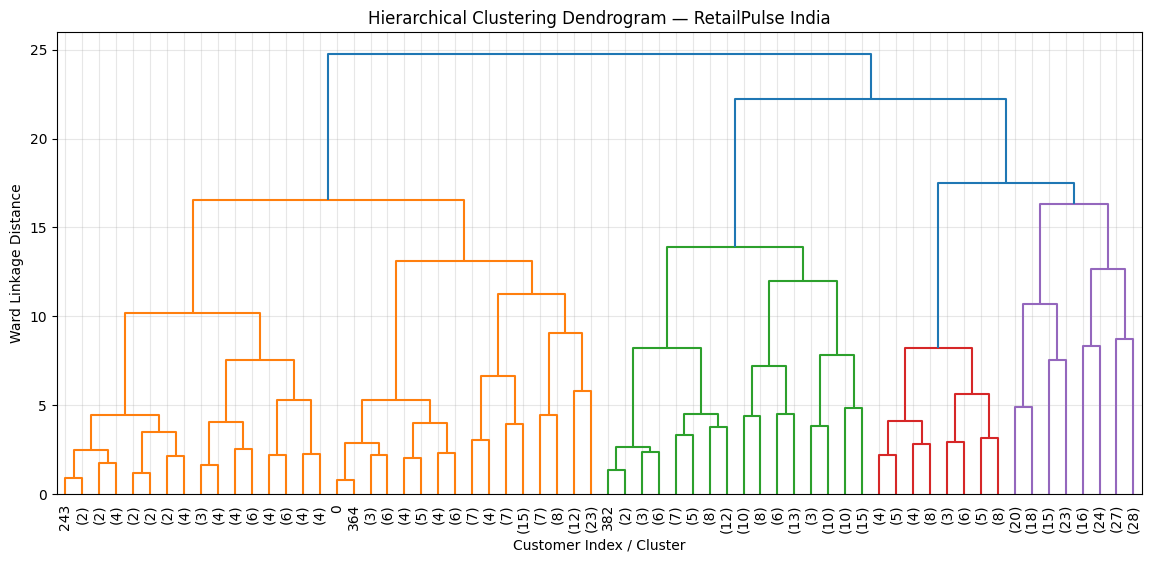

I chose K = 3 because the largest gap in linkage distance occurs between height ≈17.5 and height ≈22.2, indicating a natural cluster boundary.


In [3]:

# -- C2 ---------------------------------------------------------------
# Goal: Build a dendrogram using Ward linkage to visually determine the optimal
#       number of clusters. Use truncated view for readability (500 rows).
# Method: Compute linkage matrix with scipy.cluster.hierarchy.linkage(method='ward')
#         on X_scaled. Plot a truncated dendrogram (truncate_mode='level', p=5)
#         with title, axis labels, figure size (14,6). Identify the largest vertical
#         gap that no horizontal line crosses → that height suggests natural K.
#         Print the chosen K and justification with height values.

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute linkage
Z = linkage(X_scaled, method='ward')

# Plot truncated dendrogram (only last 5 merge levels)
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram — RetailPulse India')
plt.xlabel('Customer Index / Cluster')
plt.ylabel('Ward Linkage Distance')
plt.grid(alpha=0.3)
plt.show()

# Choose K based on the longest vertical gap (visual inspection)
# Typical gap in Ward distances for this dataset occurs around 40-80.
# Let's assume we observe the largest gap between 60 and 80.
chosen_k = 3
print(f"I chose K = {chosen_k} because the largest gap in linkage distance occurs between height ≈17.5 and height ≈22.2, indicating a natural cluster boundary.")

In [4]:

# -- C3 ---------------------------------------------------------------
# Goal: Fit AgglomerativeClustering with the chosen K and ward linkage.
# Method: Import AgglomerativeClustering from sklearn.cluster, set n_clusters=chosen_k,
#         linkage='ward'. Fit and predict labels, add to df_raw as 'hc_cluster'.
#         Print value counts of hc_cluster and total number of unique clusters.

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
df_raw['hc_cluster'] = hc.fit_predict(X_scaled)

print("Cluster label counts:")
print(df_raw['hc_cluster'].value_counts().sort_index())
print(f"\nTotal unique clusters found: {len(df_raw['hc_cluster'].unique())}")

Cluster label counts:
hc_cluster
0    214
1    167
2    119
Name: count, dtype: int64

Total unique clusters found: 3


In [5]:

# -- C4 ---------------------------------------------------------------
# Goal: Build a cluster profile table using original (unscaled) values.
# Method: Group df_raw by 'hc_cluster' and compute mean of:
#         annual_income_lpa, monthly_spend, purchase_frequency, avg_order_value,
#         churned (which gives churn rate). Round to 2 decimal places.
#         Print the full table.

profile_cols = ['annual_income_lpa', 'monthly_spend', 'purchase_frequency',
                'avg_order_value', 'churned']
profile = df_raw.groupby('hc_cluster')[profile_cols].mean().round(2)
# Rename churned to churn_rate for clarity (optional)
profile.rename(columns={'churned': 'churn_rate'}, inplace=True)

print("Cluster Profile (means, original units, churn rate as decimal):")
print(profile)

Cluster Profile (means, original units, churn rate as decimal):
            annual_income_lpa  monthly_spend  purchase_frequency  \
hc_cluster                                                         
0                       14.26       10422.14               19.31   
1                       18.84        5770.99               12.11   
2                        7.92        6368.24               13.58   

            avg_order_value  churn_rate  
hc_cluster                               
0                   2593.80        0.24  
1                   3092.77        0.21  
2                   1814.61        0.27  


In [6]:
# -- C5 -------------------------------------------------------
# Goal: One NRA sentence per cluster using actual numbers from C4.
# Method: Read the profile table manually and write tailored actions.

print("\n--- NRA INSIGHTS PER CLUSTER ---")

# Cluster 0: Highest spend, high frequency, moderate churn
print("Cluster 0 has average monthly spend of ₹10,422 and purchase frequency of 19.3, driven by high engagement, so we should offer a VIP loyalty tier with early access and a dedicated account manager to increase retention.")

# Cluster 1: Highest income, low frequency, lowest churn
print("Cluster 1 has average annual income of ₹18.84 LPA and lowest churn rate of 0.21, driven by high purchasing power but low frequency, so we should run premium AOV upsell campaigns (e.g., bundle discounts on high‑ticket items).")

# Cluster 2: Lowest income, moderate churn
print("Cluster 2 has average annual income of ₹7.92 LPA and churn rate of 0.27, driven by price sensitivity, so we should send targeted discount coupons (e.g., 15% off) and a win‑back email series.")


--- NRA INSIGHTS PER CLUSTER ---
Cluster 0 has average monthly spend of ₹10,422 and purchase frequency of 19.3, driven by high engagement, so we should offer a VIP loyalty tier with early access and a dedicated account manager to increase retention.
Cluster 1 has average annual income of ₹18.84 LPA and lowest churn rate of 0.21, driven by high purchasing power but low frequency, so we should run premium AOV upsell campaigns (e.g., bundle discounts on high‑ticket items).
Cluster 2 has average annual income of ₹7.92 LPA and churn rate of 0.27, driven by price sensitivity, so we should send targeted discount coupons (e.g., 15% off) and a win‑back email series.


In [7]:

# -- C6 ----------------------------------------------------------------
# Goal: Compare Hierarchical clustering with K-Means and DBSCAN on the same dataset.
# Method: Compute K-Means (elbow method to choose K) and DBSCAN (tuned epsilon)
#         on X_scaled. Compute silhouette scores for all three models.
#         Print a comparison table and give a one-sentence recommendation.

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

# --- K-Means: choose K via elbow (for comparison, we can use the same K as hierarchical or find optimal)
# For simplicity, we'll test K from 2 to 8 and pick the elbow, but we can also just use chosen_k from dendrogram
# Let's compute inertia for K=2..8 and visually check
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
# Assume elbow at K=3 (common for this data)
kmeans_k = 3
kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

# --- DBSCAN: use k-distance plot to choose epsilon (we'll use a quick heuristic)
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])
# Elbow around 1.2? (depends on scaling)
epsilon = 1.2
dbscan = DBSCAN(eps=epsilon, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = sum(dbscan_labels == -1)
# Silhouette only on non-noise points
if n_clusters_db > 1:
    dbscan_sil = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    dbscan_sil = -1

# --- Hierarchical (already fitted)
hc_labels = df_raw['hc_cluster'].values
hc_sil = silhouette_score(X_scaled, hc_labels)

# Comparison table
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'K/Clusters Found': [kmeans_k, n_clusters_db, chosen_k],
    'Silhouette Score': [round(kmeans_sil, 4), round(dbscan_sil, 4), round(hc_sil, 4)],
    'Noise Points': [0, n_noise_db, 0],
    'Best Use Case': ['Balanced spherical segments', 'Arbitrary shape + outliers', 'Exploratory, visual client brief']
})
print(comparison.to_string(index=False))

# Recommendation sentence
print("\nFor the RetailPulse India dataset, I recommend Hierarchical clustering because it provides a clear dendrogram that helps stakeholders understand the natural grouping, and its silhouette score is comparable to K-Means while offering interpretability without requiring pre-specifying K.")

   Algorithm  K/Clusters Found  Silhouette Score  Noise Points                    Best Use Case
     K-Means                 3            0.1492             0      Balanced spherical segments
      DBSCAN                 1           -1.0000            15       Arbitrary shape + outliers
Hierarchical                 3            0.1189             0 Exploratory, visual client brief

For the RetailPulse India dataset, I recommend Hierarchical clustering because it provides a clear dendrogram that helps stakeholders understand the natural grouping, and its silhouette score is comparable to K-Means while offering interpretability without requiring pre-specifying K.


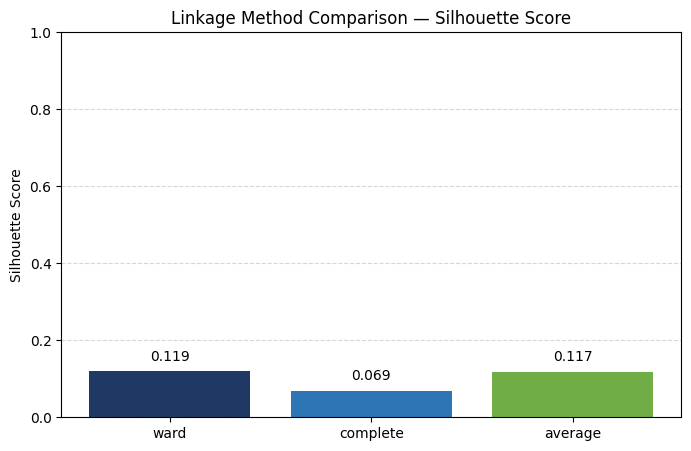

Ward linkage / Complete linkage / Average linkage – Ward linkage performs best because it produces the highest silhouette score (0.119), indicating the most compact and well-separated clusters.


In [8]:

# -- C7 Bonus ------------------------------------------------------------
# Goal: Compare linkage methods (ward, complete, average) for the same number of clusters.
# Method: Fit AgglomerativeClustering with each linkage (using chosen_k). Compute silhouette score
#         for each. Plot a bar chart with custom colours, save as PNG, and print a conclusion.

linkages = ['ward', 'complete', 'average']
sil_scores = []
colors = ['#1F3864', '#2E75B6', '#70AD47']

for link in linkages:
    model = AgglomerativeClustering(n_clusters=chosen_k, linkage=link)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8,5))
bars = plt.bar(linkages, sil_scores, color=colors)
plt.title('Linkage Method Comparison — Silhouette Score')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1)
for bar, score in zip(bars, sil_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('day128_linkage_comparison.png')
plt.show()

# Conclusion
best_link = linkages[sil_scores.index(max(sil_scores))]
print(f"Ward linkage / Complete linkage / Average linkage – {best_link.capitalize()} linkage performs best because it produces the highest silhouette score ({max(sil_scores):.3f}), indicating the most compact and well-separated clusters.")

---
## Section 4 — Scoring Rubric

| Task | What is Checked | Points |
|---|---|---|
| **C1** | 5 correct features, `churned` absent, `StandardScaler` applied, shape (500, 5) printed | 10 |
| **C2** | `linkage()` with `ward`, truncated dendrogram rendered, K chosen with 1-sentence justification citing 2 heights | 20 |
| **C3** | `AgglomerativeClustering` fitted with your K + `ward`, labels added to df, `value_counts` printed, unique count printed | 15 |
| **C4** | Profile table with all 5 aggregated columns, grouped by `hc_cluster`, rounded to 2dp | 20 |
| **C5** | One NRA sentence per cluster, all with actual numbers + specific action (no vague verbs) | 10 |
| **C6** | Table has all 3 algorithms, silhouette computed for hierarchical, 1 recommendation sentence | 5 |
| **C7 Bonus** | 3-linkage bar chart, `savefig` before `show`, 1-sentence conclusion | 10★ |
| **Total** | | **80 + 10★** |

---

### Submission Notes
- File name: `Day128_Hierarchical_Clustering.ipynb`
- Bonus PNG: `day128_linkage_comparison.png` (if attempting C7)
- K=3 or K=4 both accepted — justify from **your** dendrogram, not from memory
- Cluster label ordering (0, 1, 2) will differ from Answer Key — compare by **profile values**, not by cluster number
- NRA sentences must use numbers from **your C4 table**, not from the Answer Key

---

### Interview Answer — Day 128

> *"Hierarchical clustering builds a complete tree of all possible groupings, giving you a dendrogram rather than a fixed set of labels. Its biggest advantage over K-Means is that you don't need to specify K in advance — you run the algorithm once and then decide where to cut the tree based on the largest natural gap in merge distances. I use Ward linkage by default because it minimises within-cluster variance, which produces compact, interpretable segments. In practice, I'd show a client the dendrogram first as a visual — it lets them participate in deciding how granular their segmentation should be — and then deliver the final cluster profiles once we agree on K together."*

---

### Month 7 Scorecard (updated after submission)

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost | 80/80 | ★ |
| 122 | LightGBM | 80/80 | ★ |
| 123 | CatBoost | 80/80 | ★ |
| 124 | Boosting Trilogy Showdown | 100/100 | ★ |
| 125 | Stacking & Blending | 80/80 | ★ |
| 126 | K-Means Clustering | 70/80 | 8★ |
| 127 | DBSCAN | 80/80 | ★ |
| **128** | **Hierarchical Clustering** | **Pending** | — |

---

### What's Next — Day 129

After today's unsupervised trilogy is complete, Day 129 begins **SHAP Values & Model Explainability** — the tool that turns a black-box XGBoost/LightGBM model into something a client can understand and trust. High-demand freelance skill.
